In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
from statsmodels.tsa.vector_ar.vecm import VECM, coint_johansen

In [56]:
data = pd.read_csv('data/data.csv')
data['quarter'] = pd.PeriodIndex(data['quarter'], freq='Q')
data = data.set_index('quarter')
data = data.dropna()

data.head()

,real_GDP,cpi_level,unemp_rate,agg_deposits,base_rate,cpi_rate
quarter,,,,,,
2001Q1,457680,53.8,5.1,7.7,5.86,0.938086
2001Q2,459620,54.6,5.0,8.5,5.36,1.486989
2001Q3,462016,54.6,5.1,8.4,5.05,1.486989
2001Q4,463404,54.6,5.2,8.4,4.23,0.924214
2002Q1,464698,54.6,5.2,8.1,4.00,1.486989


## sVAR

In [57]:
df = data.copy()

df['cpi_rate'] = np.log(df['cpi_rate'].replace(0, 1e-6)).diff()
df['agg_deposits'] = np.log(df['agg_deposits']).diff()
df['base_rate'] = df['base_rate'].diff()
df['unemp_rate'] = df['unemp_rate'].diff()
df = df.drop(columns=['real_GDP', 'cpi_level'])
df = (df - df.mean()) / df.std()

df = df.dropna()

In [58]:
from statsmodels.tsa.stattools import adfuller

for col in df.columns:
    result = adfuller(df[col], autolag='AIC')
    print(f"{col}: ADF stat={result[0]:.3f}, p={result[1]:.3f}")

unemp_rate: ADF stat=-4.244, p=0.001
agg_deposits: ADF stat=-5.489, p=0.000
base_rate: ADF stat=-3.862, p=0.002
cpi_rate: ADF stat=-5.476, p=0.000


In [59]:
var_model = VAR(df)
lag_order = var_model.select_order(maxlags=4)
print(lag_order.summary())

p=2

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0    0.003538      0.1139       1.004     0.04806
1     -0.7722    -0.2204*      0.4622     -0.5496
2    -0.9848*    0.008468     0.3745*    -0.5841*
3     -0.8093      0.6255      0.4487     -0.2304
4     -0.9066      0.9697      0.4111     -0.1496
-------------------------------------------------


In [60]:
df = df[['base_rate', 'cpi_rate', 'unemp_rate', 'agg_deposits']]

B_restriction = np.array([
    [1.0, 0.0, 0.0, 0.0],
    ['E', 1.0, 0.0, 0.0],
    ['E', 'E', 1.0, 0.0],
    ['E', 'E', 'E', 1.0],
], dtype=object)

model = SVAR(df, svar_type='B', B=B_restriction)
res = model.fit(maxlags=2, solver='nm')

/Users/oliver/Documents/retail_deposit_elasticity/.venv/lib/python3.13/site-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method nm is: xtol, ftol, maxfun. The list of unsupported keyword arguments passed include: gtol. After release 0.14, this will raise.
  warnings.warn(


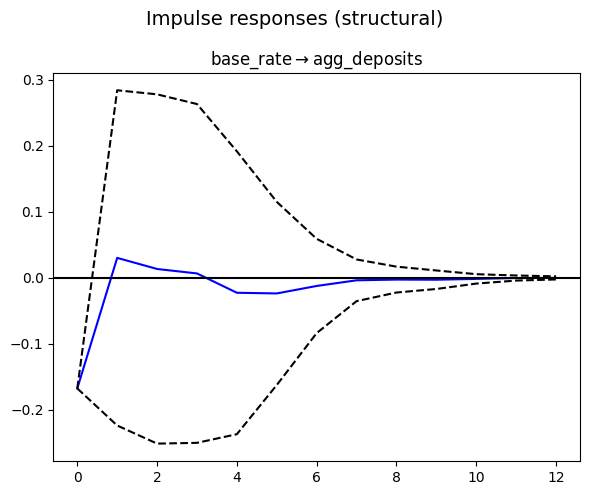

In [61]:
irf = res.irf(12)
irf.plot(figsize=(6,5), impulse='base_rate', response='agg_deposits', orth=False)
plt.tight_layout()
plt.show()

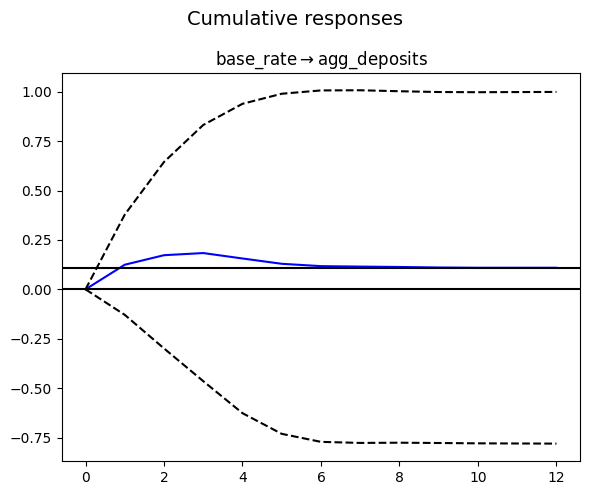

In [62]:
irf.plot_cum_effects(figsize=(6,5), impulse='base_rate', response='agg_deposits', orth=False)
plt.tight_layout()
plt.show()

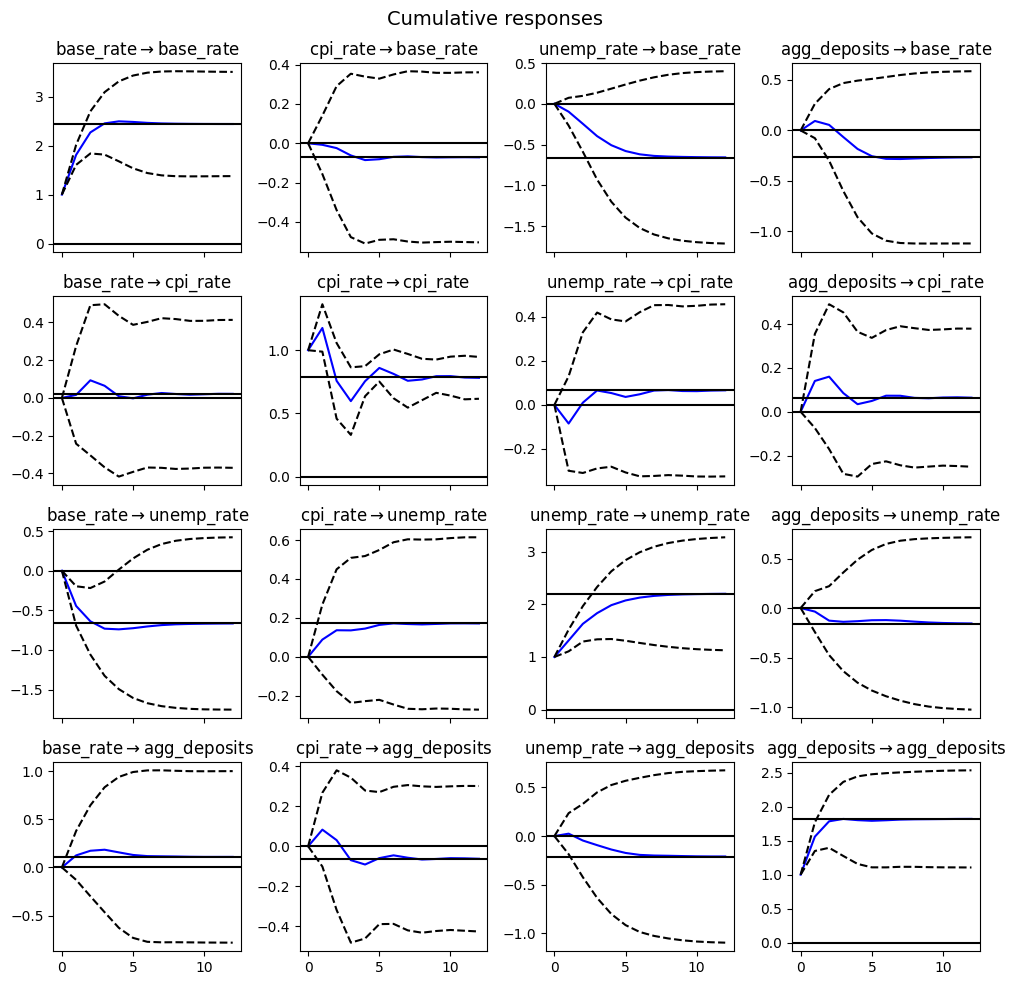

In [63]:
irf.plot_cum_effects(orth=False)
plt.tight_layout()

## VECM

In [64]:
df = data.copy()

df['real_GDP'] = np.log(df['real_GDP'])
df['cpi_rate'] = df['cpi_rate'].replace(0, 1e-6)
df['agg_deposits'] = np.log(df['agg_deposits'])
df['base_rate'] = df['base_rate']
df['unemp_rate'] = df['unemp_rate']
df = (df - df.mean()) / df.std()

# real_gdp → cpi_rate → unemp_rate → agg_deposits → base_rate
# df = df[['real_GDP', 'cpi_rate', 'unemp_rate', 'agg_deposits', 'base_rate']]
# df = df[['base_rate', 'cpi_rate', 'unemp_rate', 'agg_deposits']]
# df = df[['base_rate', 'cpi_rate', 'real_GDP', 'agg_deposits']]
df = df[['cpi_rate', 'real_GDP', 'base_rate', 'agg_deposits']]

df = df.dropna()

In [65]:
for col in df.columns:
    result = adfuller(df[col], autolag='AIC')
    print(f"{col}: ADF stat={result[0]:.3f}, p={result[1]:.3f}")

cpi_rate: ADF stat=-1.857, p=0.353
real_GDP: ADF stat=-1.382, p=0.591
base_rate: ADF stat=-1.798, p=0.381
agg_deposits: ADF stat=-1.705, p=0.428


In [66]:
for col in df.columns:
    result = adfuller(df[col].diff().dropna(), autolag='AIC')
    print(f"{col}: ADF stat={result[0]:.3f}, p={result[1]:.3f}")

cpi_rate: ADF stat=-3.821, p=0.003
real_GDP: ADF stat=-9.013, p=0.000
base_rate: ADF stat=-3.862, p=0.002
agg_deposits: ADF stat=-5.489, p=0.000


In [67]:
var_model = VAR(df)
lag_order = var_model.select_order(maxlags=4)
print(lag_order.summary())

p=2

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0     -0.8033     -0.6936      0.4479     -0.7590
1      -10.38      -9.831   3.107e-05      -10.16
2      -11.23     -10.25*   1.327e-05     -10.83*
3      -11.22      -9.798   1.346e-05      -10.65
4     -11.29*      -9.421  1.277e-05*      -10.53
-------------------------------------------------


In [68]:
result = coint_johansen(df, det_order=1, k_ar_diff=p-1)
print(result.lr1)   # trace statistics
print(result.cvt)   # critical values

r=2

[74.12868438 36.63682373 17.52708934  4.16039491]
[[51.6492 55.2459 62.5202]
 [32.0645 35.0116 41.0815]
 [16.1619 18.3985 23.1485]
 [ 2.7055  3.8415  6.6349]]


In [69]:
vecm = VECM(df, k_ar_diff=p-1, coint_rank=r, deterministic='co')
vecm_fit = vecm.fit()
print(vecm_fit.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation cpi_rate
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0040      0.029      0.140      0.889      -0.053       0.061
L1.cpi_rate         0.4322      0.106      4.065      0.000       0.224       0.641
L1.real_GDP        -0.0381      0.100     -0.380      0.704      -0.235       0.158
L1.base_rate        0.0380      0.168      0.226      0.821      -0.292       0.367
L1.agg_deposits    -0.0550      0.087     -0.633      0.527      -0.225       0.115
Det. terms outside the coint. relation & lagged endog. parameters for equation real_GDP
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0485      0.030      1.603      0.109      -0.

In [70]:
irf = vecm_fit.irf(20)

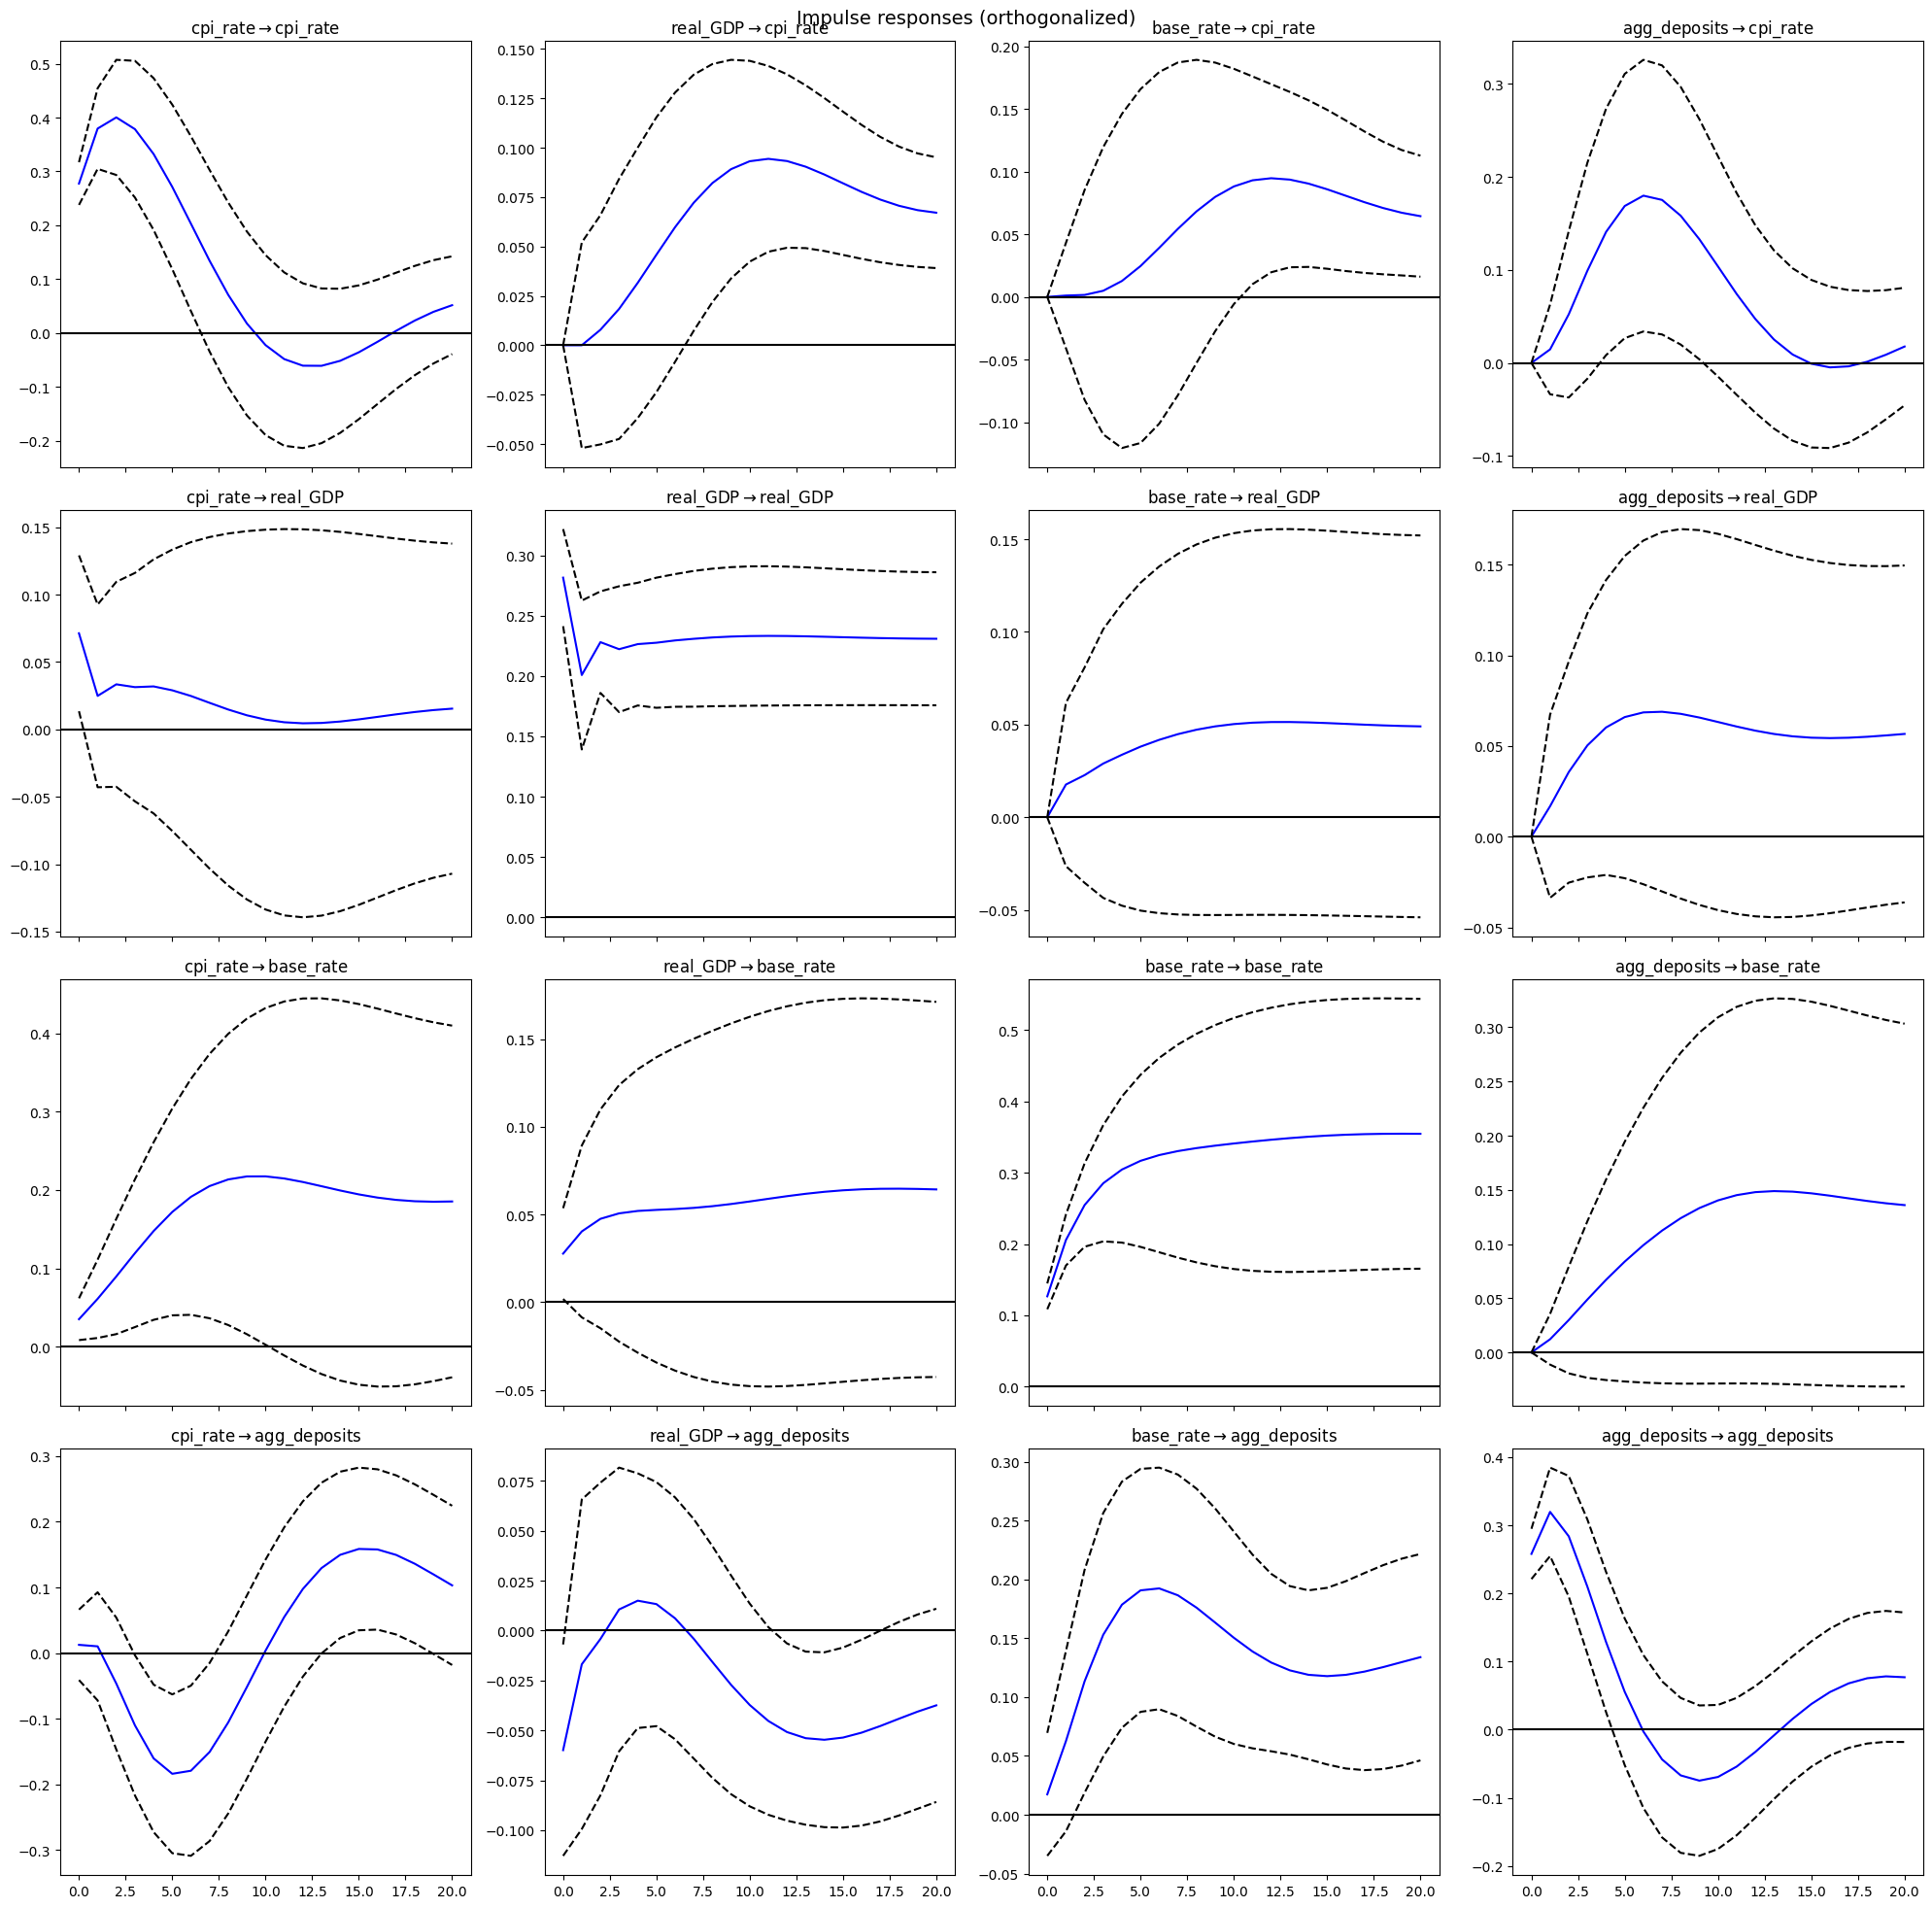

In [71]:
irf.plot(figsize=(20,20), orth=True)
plt.tight_layout()
plt.show()